Instructions to Run the Notebook

1. Open this notebook in Kaggle.
2. Add the dataset using the following link: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
3. Set the accelerator to GPU (T4 recommended).
4. Ensure GPU is enabled before running the notebook.
5. Run all cells sequentially.

In [1]:
# Importing the required libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

import pandas as pd
import numpy as np
from PIL import Image, ImageOps
import os
import re
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer
import nltk
from nltk.translate.meteor_score import meteor_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Setting up the GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Loading the dataset and setting the paths

Data_Path = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/"
Image_Path = os.path.join(Data_Path, "images", "images_normalized")
Reports_Data = os.path.join(Data_Path, "indiana_reports.csv")
Projections_Data = os.path.join(Data_Path, "indiana_projections.csv")

In [4]:
# Setting up the hyperparameters 

BATCH_SIZE = 32
LEARNING_RATE_CLASSIFIER = 3e-4 
LEARNING_RATE_GENERATOR = 3e-4 
NUM_EPOCHS = 20 
EMBED_SIZE = 256
HIDDEN_SIZE = 512
BEAM_WIDTH = 3 

In [5]:
# Loading the datasets and filtering out the labels

print("Loading the data and filtering out the frontal images")
Reports_df = pd.read_csv(Reports_Data)
Projections_df = pd.read_csv(Projections_Data)
Projections_df = Projections_df[Projections_df['projection'] == 'Frontal']

df = pd.merge(Reports_df, Projections_df, on='uid')
df['report'] = df['findings'].fillna('') + ' ' + df['impression'].fillna('')
df = df[['uid', 'MeSH', 'filename', 'report']].dropna(subset=['MeSH']).drop_duplicates(subset=['filename'])

Anatomy_Labels = {
    'lung', 'spine', 'aorta', 'thoracic vertebrae', 'heart', 'ribs', 'pleura', 
    'diaphragm', 'bones', 'bone', 'abdomen', 'shoulder', 'sternum', 'clavicle', 
    'mediastinum', 'trachea', 'normal', 'medical device', 'surgical instruments', 
    'implant', 'catheters', 'device removal', 'blood vessels', 'markings', 
    'soft tissue', 'lymph nodes', 'bronchi', 'pulmonary artery'
}

# Extracting the diseases

def Disease_Extraction(text):
    if pd.isna(text) or text.lower() == 'normal': return []
    findings = text.lower().split(';')
    clean_list = {item.split('/')[0].strip() for item in findings if item.split('/')[0].strip()}
    return [item for item in clean_list if item not in Anatomy_Labels]

df['raw_pathologies'] = df['MeSH'].apply(Disease_Extraction)

Loading the data and filtering out the frontal images


In [6]:
# Filtering out the target diseases suitable for frontal images

Target_Diseases = [
    'opacity', 'cardiomegaly', 'pulmonary atelectasis', 'pleural effusion'
]
print(f"Targeting Core Health Issues: {Target_Diseases}")

def Final_Label_Assignment(Disease_List):
    filtered = [l for l in Disease_List if l in Target_Diseases]
    return filtered if filtered else ['normal']

df['labels'] = df['raw_pathologies'].apply(Final_Label_Assignment)

mlb = MultiLabelBinarizer()
df['encoded_labels'] = list(mlb.fit_transform(df['labels']))
num_classes = len(mlb.classes_)
print(f"Final Class List: {mlb.classes_}")

Targeting Core Health Issues: ['opacity', 'cardiomegaly', 'pulmonary atelectasis', 'pleural effusion']
Final Class List: ['cardiomegaly' 'normal' 'opacity' 'pleural effusion'
 'pulmonary atelectasis']


In [7]:
# Cleaning the test

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}
        self.freq_threshold = freq_threshold
        
    def __len__(self): return len(self.itos)
    
    def Tokenizing(self, text):
        text = text.lower()
        text = re.sub(r'[^\w\s.]', '', text)
        return re.sub(r'\s+', ' ', text).strip().split(' ')
        
    def Vocabulary_Building(self, sentence_list):
        frequencies = Counter()
        for s in sentence_list:
            for w in self.Tokenizing(s): frequencies[w] += 1
        idx = 4
        for w, count in frequencies.items():
            if count >= self.freq_threshold:
                self.itos[idx] = w; self.stoi[w] = idx; idx += 1
                
    def Numerizing(self, text): 
        return [self.stoi.get(w, self.stoi["<UNK>"]) for w in self.Tokenizing(text)]

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

vocab = Vocabulary(freq_threshold=5)
vocab.Vocabulary_Building(train_df['report'].tolist())

# Creating the XRay dataset vocabulary after cleaning

class XRayDataset(Dataset):
    def __init__(self, df, transform, vocab=None, is_generator=False): 
        self.df = df; self.transform = transform; self.vocab = vocab; self.is_generator = is_generator
        
    def __len__(self): return len(self.df)
    
    def __getitem__(self, index):
        row = self.df.iloc[index]
        labels = torch.FloatTensor(row['encoded_labels'])
        if not self.is_generator:
            image = Image.open(os.path.join(Image_Path, row['filename'])).convert("RGB")
            return self.transform(image), labels
        else:
            num_rep = [self.vocab.stoi["<SOS>"]] + self.vocab.Numerizing(row['report']) + [self.vocab.stoi["<EOS>"]]
            return labels, torch.tensor(num_rep)

In [8]:
# Performing data augmentation on the images

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomAutocontrast(p=0.5), 
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(10),
    transforms.CenterCrop(224), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), value=0) 
])

val_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_loader_cls = DataLoader(XRayDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_cls = DataLoader(XRayDataset(val_df, val_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class GenCollate:
    def __init__(self, pad_idx): self.pad_idx = pad_idx
    def __call__(self, batch):
        labels = torch.stack([item[0] for item in batch], 0)
        reports = nn.utils.rnn.pad_sequence([item[1] for item in batch], batch_first=True, padding_value=self.pad_idx)
        return labels, reports

train_loader_gen = DataLoader(XRayDataset(train_df, None, vocab, True), batch_size=BATCH_SIZE, shuffle=True, collate_fn=GenCollate(vocab.stoi["<PAD>"]), num_workers=2)

In [9]:
# Building the architecture of the classifier and transformer

class ChestXrayClassifier(nn.Module):
    def __init__(self, n_classes):
        super(ChestXrayClassifier, self).__init__()
        # Deeper Backbone: DenseNet-169
        self.densenet = models.densenet169(weights=models.DenseNet169_Weights.DEFAULT)
        for param in self.densenet.features.parameters():
            param.requires_grad = False
        self.densenet.classifier = nn.Linear(self.densenet.classifier.in_features, n_classes)
        
    def forward(self, x): return self.densenet(x)

class WeightedFocalLoss(nn.Module):
    def __init__(self, pos_weight, gamma=2.0):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none', pos_weight=self.pos_weight)
        probas = torch.sigmoid(inputs)
        p_t = probas * targets + (1 - probas) * (1 - targets)
        focal_modulator = (1 - p_t) ** self.gamma
        loss = focal_modulator * bce_loss
        return loss.mean()

class ReportGeneratorTransformer(nn.Module):
    def __init__(self, n_classes, embed_size, vocab_size, n_head=4, n_layers=3, dropout=0.1):
        super(ReportGeneratorTransformer, self).__init__()
        self.label_encoder = nn.Linear(n_classes, embed_size)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_encoder = nn.Parameter(torch.zeros(1, 512, embed_size))
        decoder_layer = nn.TransformerDecoderLayer(d_model=embed_size, nhead=n_head, dropout=dropout, batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        self.fc_out = nn.Linear(embed_size, vocab_size)
        
    def Generating_Masks(self, sz): 
        return torch.triu(torch.full((sz, sz), float('-inf')), diagonal=1).to(device)
        
    def forward(self, labels, reports):
        memory = self.label_encoder(labels).unsqueeze(1)
        tgt_emb = self.embedding(reports[:, :-1]) + self.pos_encoder[:, :reports.size(1)-1, :]
        tgt_mask = self.Generating_Masks(tgt_emb.size(1))
        output = self.transformer_decoder(tgt_emb, memory, tgt_mask=tgt_mask)
        return self.fc_out(output)

In [10]:
# Training the classifier on the dataset

classifier = ChestXrayClassifier(num_classes).to(device)

print("\nCalculating the weights for Focal Loss")
class_counts = np.sum(train_df['encoded_labels'].tolist(), axis=0)
pos_weight = (len(train_df) - class_counts) / (class_counts + 1e-6)
pos_weight_tensor = torch.sqrt(torch.tensor(pos_weight, dtype=torch.float)).to(device)

criterion_cls = WeightedFocalLoss(pos_weight=pos_weight_tensor, gamma=2.0)
optimizer_cls = optim.AdamW(filter(lambda p: p.requires_grad, classifier.parameters()), lr=LEARNING_RATE_CLASSIFIER)
scheduler_cls = optim.lr_scheduler.StepLR(optimizer_cls, step_size=5, gamma=0.5)

print("Training the classifier")
for epoch in range(NUM_EPOCHS):
    if epoch == 5:
        print("[Unfreezing DenseBlock4 & Norm5 for fine-tuning the model further]")
        for param in classifier.densenet.features.denseblock4.parameters(): param.requires_grad = True
        for param in classifier.densenet.features.norm5.parameters(): param.requires_grad = True
        optimizer_cls = optim.AdamW(filter(lambda p: p.requires_grad, classifier.parameters()), lr=scheduler_cls.get_last_lr()[0])
        scheduler_cls = optim.lr_scheduler.StepLR(optimizer_cls, step_size=5, gamma=0.5)

    classifier.train()
    total_loss = 0
    for images, labels in train_loader_cls:
        images, labels = images.to(device), labels.to(device)
        optimizer_cls.zero_grad()
        loss = criterion_cls(classifier(images), labels)
        loss.backward()
        optimizer_cls.step()
        total_loss += loss.item()
        
    scheduler_cls.step()
    print(f"Classifier Epoch {epoch+1}/{NUM_EPOCHS} - Focal Loss: {total_loss/len(train_loader_cls):.4f} - LR: {scheduler_cls.get_last_lr()[0]:.6f}")

generator = ReportGeneratorTransformer(num_classes, EMBED_SIZE, len(vocab)).to(device)
Criteria_Generator = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
Optimizer_Generator = optim.Adam(generator.parameters(), lr=LEARNING_RATE_GENERATOR)
Scheduler_Generator = optim.lr_scheduler.StepLR(Optimizer_Generator, step_size=5, gamma=0.5)

# Training the transformer using the labels predicted and training data

print("\nTraining the transformer")
for epoch in range(NUM_EPOCHS): 
    generator.train()
    total_loss = 0
    for labels, reports in train_loader_gen:
        labels, reports = labels.to(device), reports.to(device)
        Optimizer_Generator.zero_grad()
        outputs = generator(labels, reports)
        loss = Criteria_Generator(outputs.view(-1, outputs.shape[-1]), reports[:, 1:].reshape(-1))
        loss.backward()
        Optimizer_Generator.step()
        total_loss += loss.item()
        
    Scheduler_Generator.step()
    print(f"Generator Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {total_loss/len(train_loader_gen):.4f} - LR: {Scheduler_Generator.get_last_lr()[0]:.6f}")

Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 123MB/s] 



Calculating the weights for Focal Loss
Training the classifier
Classifier Epoch 1/20 - Focal Loss: 0.1523 - LR: 0.000300
Classifier Epoch 2/20 - Focal Loss: 0.1396 - LR: 0.000300
Classifier Epoch 3/20 - Focal Loss: 0.1339 - LR: 0.000300
Classifier Epoch 4/20 - Focal Loss: 0.1319 - LR: 0.000300
Classifier Epoch 5/20 - Focal Loss: 0.1294 - LR: 0.000150
[Unfreezing DenseBlock4 & Norm5 for fine-tuning the model further]
Classifier Epoch 6/20 - Focal Loss: 0.1258 - LR: 0.000150
Classifier Epoch 7/20 - Focal Loss: 0.1064 - LR: 0.000150
Classifier Epoch 8/20 - Focal Loss: 0.0944 - LR: 0.000150
Classifier Epoch 9/20 - Focal Loss: 0.0845 - LR: 0.000150
Classifier Epoch 10/20 - Focal Loss: 0.0768 - LR: 0.000075
Classifier Epoch 11/20 - Focal Loss: 0.0668 - LR: 0.000075
Classifier Epoch 12/20 - Focal Loss: 0.0596 - LR: 0.000075
Classifier Epoch 13/20 - Focal Loss: 0.0538 - LR: 0.000075
Classifier Epoch 14/20 - Focal Loss: 0.0490 - LR: 0.000075
Classifier Epoch 15/20 - Focal Loss: 0.0459 - LR: 0.

In [11]:
# Evaluating the classifier performance

print("\nEvaluating the classifier on the chosen metrics")

classifier.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader_cls:
        all_logits.append(classifier(images.to(device)).cpu())
        all_labels.append(labels.cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels).numpy()

best_f1_thresh, best_threshold = 0.0, 0.5
for thresh in np.arange(0.1, 0.9, 0.05):
    preds = (torch.sigmoid(all_logits) > thresh).numpy()
    f1 = f1_score(all_labels, preds, average='micro', zero_division=0)
    if f1 > best_f1_thresh:
        best_f1_thresh = f1
        best_threshold = thresh

print(f"Optimal Classifier Threshold: {best_threshold:.2f}")
print(f"Best Validation F1 Score (Micro): {best_f1_thresh:.4f}")
final_preds = (torch.sigmoid(all_logits) > best_threshold).numpy()
print("\nClassification Report (Clinical Frontal Focus):")
print(classification_report(all_labels, final_preds, target_names=mlb.classes_, zero_division=0))


Evaluating the classifier on the chosen metrics
Optimal Classifier Threshold: 0.45
Best Validation F1 Score (Micro): 0.7452

Classification Report (Clinical Frontal Focus):
                       precision    recall  f1-score   support

         cardiomegaly       0.42      0.47      0.44        47
               normal       0.86      0.93      0.89       446
              opacity       0.29      0.24      0.26        62
     pleural effusion       0.57      0.35      0.43        23
pulmonary atelectasis       0.25      0.22      0.23        41

            micro avg       0.73      0.76      0.75       619
            macro avg       0.48      0.44      0.45       619
         weighted avg       0.72      0.76      0.73       619
          samples avg       0.76      0.79      0.77       619



In [12]:
# Evaluating the performance of the generator 

print("\nEvaluating the Text Generator on the Test Set using Beam Search")
generator.eval()

def Beam_Search_Generation(model, labels_tensor, vocab, max_len=50, beam_width=3):
    start_token = vocab.stoi["<SOS>"]
    eos_token = vocab.stoi["<EOS>"]
    
    beams = [([start_token], 0.0)]
    memory = model.label_encoder(labels_tensor).unsqueeze(1)
    
    for step in range(max_len):
        new_beams = []
        for seq, score in beams:
            if seq[-1] == eos_token:
                new_beams.append((seq, score))
                continue
                
            tgt = torch.LongTensor(seq).unsqueeze(0).to(device)
            out = model.fc_out(model.transformer_decoder(model.embedding(tgt), memory))
            
            probs = F.log_softmax(out[0, -1, :], dim=-1)
            top_probs, top_indices = probs.topk(beam_width)
            
            for i in range(beam_width):
                new_seq = seq + [top_indices[i].item()]
                new_score = score + top_probs[i].item() 
                new_beams.append((new_seq, new_score))
                
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]
        
        if all(seq[-1] == eos_token for seq, _ in beams):
            break
            
    best_seq = beams[0][0]
    return " ".join([vocab.itos.get(tok, "<UNK>") for tok in best_seq[1:-1] if tok != eos_token])

test_subset = test_df.head(100) 
results = []
with torch.no_grad():
    for _, row in test_subset.iterrows():
        true_labels_tensor = torch.FloatTensor(row['encoded_labels']).unsqueeze(0).to(device)
        generated_report = Beam_Search_Generation(generator, true_labels_tensor, vocab, beam_width=BEAM_WIDTH)
        results.append({
            "true_report": row['report'],
            "generated_report": generated_report
        })

results_df = pd.DataFrame(results)
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
True_Report_Tokenizing = [[r.split()] for r in results_df['true_report']]
Generators_Tokenizing = [r.split() for r in results_df['generated_report']]

print(f"BLEU-4 Score using Beam Search:  {corpus_bleu(True_Report_Tokenizing, Generators_Tokenizing):.4f}")
print(f"ROUGE-L Score: {np.mean([scorer.score(r['true_report'], r['generated_report'])['rougeL'].fmeasure for _, r in results_df.iterrows()]):.4f}")

torch.save(classifier.state_dict(), "final_classifier_clinical_focus.pth")
torch.save(generator.state_dict(), "final_generator_clinical_focus.pth")
print("\nFinal Pipeline Complete. Models saved successfully.")


Evaluating the Text Generator on the Test Set using Beam Search
BLEU-4 Score using Beam Search:  0.0213
ROUGE-L Score: 0.3033

Final Pipeline Complete. Models saved successfully.



 Displaying the sample visualisation


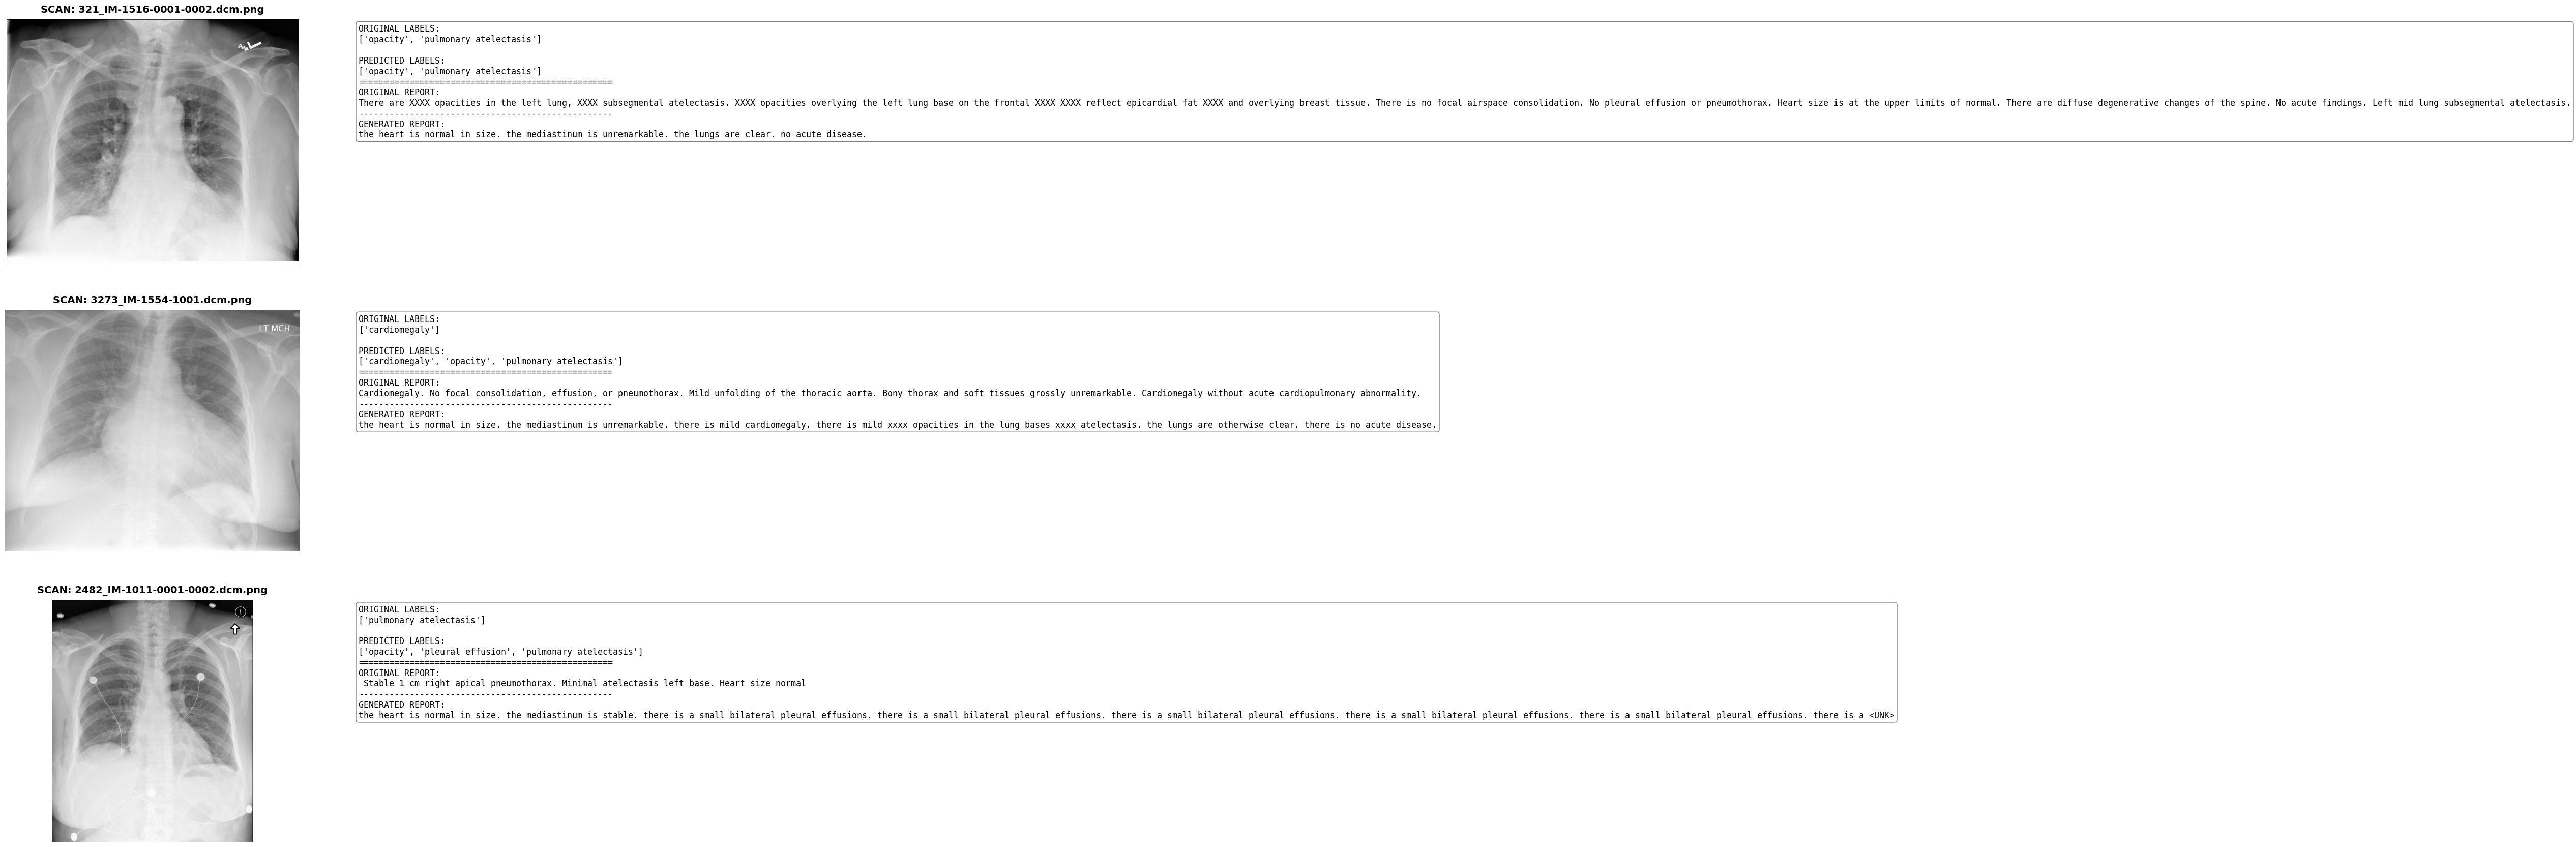

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import torch

def Sample_Visualisation(model_cls, model_gen, test_df, mlb, vocab, num_samples=3):
    Pathological_df = test_df[test_df['labels'].apply(lambda x: 'normal' not in x)].head(num_samples)
    
    if Pathological_df.empty:
        print("non-normal images were not found in this test set")
        return

    model_cls.eval()
    model_gen.eval()
    
    # Creating the display grid

    fig, axes = plt.subplots(len(Pathological_df), 2, figsize=(18, 7 * len(Pathological_df)))
    
    # handling the single sample cases

    if len(Pathological_df) == 1:
        axes = axes.reshape(1, 2)

    with torch.no_grad():
        for i, (idx, row) in enumerate(Pathological_df.iterrows()):

            # Processing the images

            img_path = os.path.join(Image_Path, row['filename'])
            raw_image = Image.open(img_path).convert("RGB")
            input_tensor = val_transform(raw_image).unsqueeze(0).to(device)
            
            # Getting the disease tags

            logits = model_cls(input_tensor)
            preds = (torch.sigmoid(logits) > best_threshold).cpu().numpy()
            pred_labels = mlb.inverse_transform(preds)[0]
            
            # Creating the medical report using the generator

            pred_labels_tensor = torch.FloatTensor(preds).to(device)
            gen_report = Beam_Search_Generation(model_gen, pred_labels_tensor, vocab)
            
            # Plotting the image

            axes[i, 0].imshow(raw_image, cmap='gray')
            axes[i, 0].set_title(f"SCAN: {row['filename']}", fontsize=14, fontweight='bold', pad=10)
            axes[i, 0].axis('off')
            
            # Displaying the text from the report

            Text_Display = (
                f"ORIGINAL LABELS:\n{row['labels']}\n\n"
                f"PREDICTED LABELS:\n{list(pred_labels)}\n"
                f"{'='*50}\n"
                f"ORIGINAL REPORT:\n{row['report']}\n"
                f"{'-'*50}\n"
                f"GENERATED REPORT:\n{gen_report}"
            )
            
            # Placing the text according to the display alignment

            axes[i, 1].text(0.01, 0.98, Text_Display, 
                            fontsize=12, 
                            verticalalignment='top', 
                            horizontalalignment='left',
                            family='monospace', 
                            transform=axes[i, 1].transAxes,
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
            axes[i, 1].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1)
    plt.show()

# Printing the sample visualisation

print("\n Displaying the sample visualisation")
Sample_Visualisation(classifier, generator, test_df, mlb, vocab, num_samples=3)